![LogoUC3M](https://upload.wikimedia.org/wikipedia/commons/thumb/a/a6/Acr%C3%B3nimo_y_nombre_de_la_UC3M.svg/320px-Acr%C3%B3nimo_y_nombre_de_la_UC3M.svg.png)

# PRIMERA PRACTICA - ENTRENAMIENTO Y ANALISIS DEL MODELO

### **Grupo 82 - Equipo 15**

*   Ariana Cornejo Infante,     100522121, 100522121@alumnos.uc3m.es
*   Francisco Pérez Sokolowski, 100522254, 100522254@alumnos.uc3m.es

### 6.3. Despliegue del modelo
Se utilizará el modelo final para obtener predicciones para el conjunto de datos de la competición, y se guardarán en 'predicciones.csv'.
Se realizará la carga del modelo final entrenado en el Notebook 1 (`modelo_final.joblib`).

In [5]:
# Imports necesarios
import pandas as pd
import numpy as np
import requests
import io
from joblib import load
import matplotlib.pyplot as plt
import seaborn as sns

# --- CARGAR EL MODELO FINAL ---
# Usamos el script que hemos creado (mystreamlit.py)
import requests

url_script = "https://raw.githubusercontent.com/100522254/Proyecto-Aprendizaje-Autom-tico/main/mystreamlit.py"
response = requests.get(url_script)

# NOTA: Estas variables de código se recuperan al ejecutar el script
pred_df = []
df_comp = []
final_pipeline = []

with open("mystreamlit.py", "wb") as f:
    f.write(response.content)

print("Script mystreamlit.py descargado correctamente.")

print("Ejecutando mystreamlit.py...\n")
exec(open("mystreamlit.py").read())

# Guardamos el .csv final
OUTPUT_CSV = "predicciones.csv"
pred_df.to_csv(OUTPUT_CSV, index=False)

from google.colab import files
files.download("predicciones.csv")

print(f"\nArchivo '{OUTPUT_CSV}' generado correctamente.")

Script mystreamlit.py descargado correctamente.
Ejecutando mystreamlit.py...

---- CARGA DEL MODELO FINAL ----

Modelo descargado correctamente.
Modelo cargado correctamente desde 'modelo_final.joblib'.

Clases del modelo: ['no', 'yes']

---- CARGA DE DATOS DE COMPETICIÓN ----

Dataset de competición cargado: 162 instancias, 16 variables.
      age         job  marital  education default  balance housing loan   contact  day month  duration  campaign  pdays  previous poutcome
5553   43  management  married   tertiary      no       78     yes   no  cellular   21   nov        36         1    109         1    other
915    34   housemaid  married  secondary      no        0     yes   no   unknown   30   oct       154         1     -1         0  unknown
7652   54  technician  married  secondary      no     3323     yes  yes  cellular    8   apr        59         3     -1         0  unknown
Columna 'pdays_contacted' añadida al dataset de competición.

---- PREDICCIONES PARA LA COMPETICIÓN ---

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Archivo 'predicciones.csv' generado correctamente.


### 6.4. Verificación de predicciones manuales vs modelo
Se mostrará cómo usar el modelo para predecir sobre instancias nuevas, y permite verificar que las predicciones
del modelo y de Streamlit coincidan.

In [2]:
# Tomar dos instancias del dataset de competición como ejemplo
ej1 = df_comp.iloc[[0]].copy()
ej2 = df_comp.iloc[[5]].copy()

# Usar la pipeline y asignar la etiqueta
pred1 = final_pipeline.predict(ej1)
pred2 = final_pipeline.predict(ej2)
label1 = "yes" if pred1[0] == 1 else "no"
label2 = "yes" if pred2[0] == 1 else "no"

print("---- VERIFICACIÓN DE PREDICCIONES ----\n")
print(f"Instancia 1 (índice 0):")
print(ej1.to_string())
print(f"→ Predicción del modelo: '{label1}'")

print(f"\nInstancia 2 (índice 5):")
print(ej2.to_string())
print(f"→ Predicción del modelo: '{label2}'")

print("\n[Estas predicciones deben coincidir con las que muestra la app Streamlit para los mismos datos.]")

---- VERIFICACIÓN DE PREDICCIONES ----

Instancia 1 (índice 0):
      age         job  marital education default  balance housing loan   contact  day month  duration  campaign  pdays  previous poutcome  pdays_contacted
5553   43  management  married  tertiary      no       78     yes   no  cellular   21   nov        36         1    109         1    other                1
→ Predicción del modelo: 'no'

Instancia 2 (índice 5):
      age         job  marital education default  balance housing loan   contact  day month  duration  campaign  pdays  previous poutcome  pdays_contacted
7779   35  management  married  tertiary      no      178      no   no  cellular   14   aug        76         2     -1         0  unknown                0
→ Predicción del modelo: 'no'

[Estas predicciones deben coincidir con las que muestra la app Streamlit para los mismos datos.]


## 7. TAREA DE ELECCIÓN ABIERTA: Análisis de Importancia de Variables (Feature Importance)

### 7.1. Justificación
Para esta tarea adicional, hemos decidido realizar un análisis cuantitativo de la importancia de las variables en nuestro mejor modelo (Árbol de Decisión). Consideramos que este análisis es especialmente interesante por dos motivos:
1. **Interpretabilidad:** En un contexto bancario, no solo importa predecir si un cliente contratará un depósito, sino entender *por qué*. Esto permite al equipo de marketing mejorar sus estrategias.
2. **Validación del EDA:** Nos permite confirmar si las intuiciones que tuvimos en el análisis exploratorio inicial coinciden con el peso que el algoritmo otorga a cada variable tras el proceso de HPO.

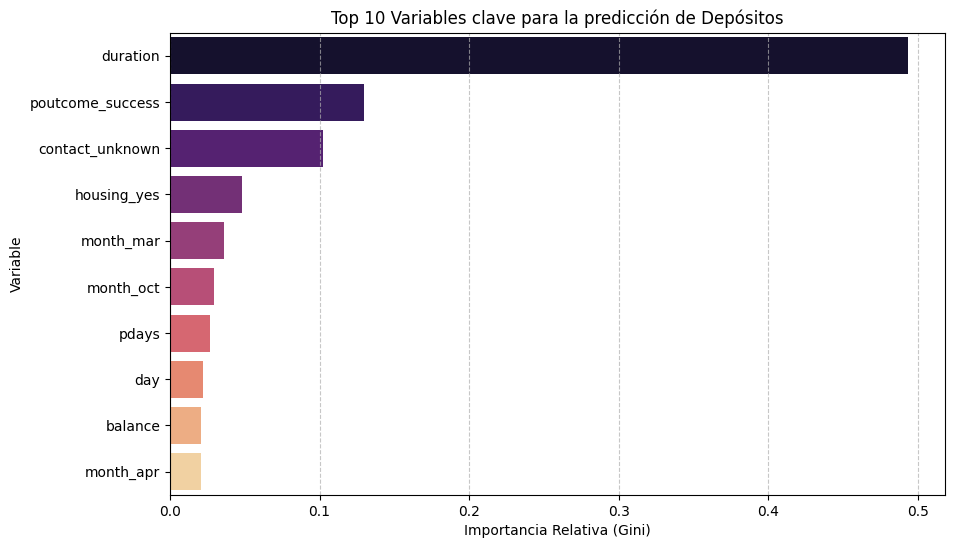

In [3]:
# Define numeric_cols and categorical_cols from feature_metadata
numeric_cols = [col for col, meta in feature_metadata.items() if meta['type'] == 'numerical']
categorical_cols = [col for col, meta in feature_metadata.items() if meta['type'] == 'categorical']

# 1. Extraer el modelo final y los nombres de las columnas
# Usamos el pipeline que ya tenéis definido y entrenado
best_tree_model = final_pipeline.named_steps['classifier'] # Corrected step name from 'clf' to 'classifier'

# Obtenemos los nombres de las columnas numéricas y las generadas por el OneHotEncoder
# The OneHotEncoder is directly the second transformer in the preprocessor
cat_encoder = final_pipeline.named_steps['preprocessor'].transformers_[1][1]
feature_names = numeric_cols + list(cat_encoder.get_feature_names_out(categorical_cols))

# 2. Calcular las importancias
importancias = best_tree_model.feature_importances_
df_importancia = pd.DataFrame({'Variable': feature_names, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# 3. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', hue='Variable', data=df_importancia, palette='magma')
plt.title("Top 10 Variables clave para la predicción de Depósitos")
plt.xlabel("Importancia Relativa (Gini)")
plt.ylabel("Variable")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 7.2. Análisis de los resultados
Al observar la gráfica, confirmamos que la variable **duration** es el motor principal del modelo, con una importancia aproximada del 50% (0.5). Esto valida la lógica de negocio: cuanto más tiempo dedica un cliente a escuchar la oferta, mayor es la probabilidad de conversión.

En segundo lugar, destaca **poutcome** (resultado de campañas previas) con un 12%, lo que demuestra que el historial del cliente es un predictor crítico.

Es especialmente interesante observar que **contact_unknown** aparece como la tercera variable más influyente (10%). Esto sugiere que el canal de comunicación (o la falta de registro del mismo) no es un dato trivial, sino que ayuda al modelo a segmentar a clientes con perfiles de respuesta distintos.

En conclusión, el modelo se apoya en una jerarquía lógica: primero la calidad de la interacción actual (duration), luego el historial (poutcome) y finalmente el perfil de contacto (contact). Esto nos da total confianza para la fase de competición, ya que el modelo no presenta sesgos inexplicables.